# Step 7. 동적 리밸런싱 + Ablation Study

**목적**: MDD 기반 얼럿 신호에 따른 성향별 동적 리밸런싱 시뮬레이션 및 Ablation Study

**구성**:
- 7-1. 성향별 동적 리밸런싱 규칙 (4 프로파일 × 4 얼럿 설정)
- 7-2. Ablation Study: 16개 시뮬레이션 + 2 벤치마크 비교
- 7-3. Bootstrap 유의성 검정
- 7-4. 핵심 발견 및 결론

**데이터**: 30개 자산 (2016~2025), 4개 얼럿 설정 (A/B/C/D), 4개 투자 성향

In [1]:
# ── Imports & Data Loading ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager as fm
import warnings, os, pathlib

warnings.filterwarnings('ignore')

# Font
font_path = pathlib.Path('C:/Windows/Fonts/malgun.ttf')
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# Paths
DATA = pathlib.Path('data')
IMG  = pathlib.Path('images')
IMG.mkdir(exist_ok=True)

# Load data
prices  = pd.read_csv(DATA / 'portfolio_prices.csv', parse_dates=['Date'], index_col='Date')
alerts  = pd.read_csv(DATA / 'alert_signals.csv',    parse_dates=['Date'], index_col='Date')
profiles_df = pd.read_csv(DATA / 'profiles.csv')

# Asset tickers & group indices
PORT_TICKERS = ['SPY','QQQ','IWM','EFA','EEM','TLT','AGG','SHY','TIP','GLD','DBC',
                'XLK','XLF','XLE','XLV','VOX','XLY','XLP','XLI','XLU','XLRE','XLB',
                'AAPL','MSFT','AMZN','GOOGL','JPM','JNJ','PG','XOM']

EQUITY_IDX = list(range(0,5)) + list(range(11,30))   # SPY~EEM(0-4), XLK~XOM(11-29)
BOND_IDX   = list(range(5,9))                         # TLT, AGG, SHY, TIP
GOLD_IDX   = [9, 10]                                  # GLD, DBC

# Alert column mapping (csv uses lowercase)
ALERT_COLS = {'ALERT_A': 'alert_a', 'ALERT_B': 'alert_b',
              'ALERT_C': 'alert_c', 'ALERT_D': 'alert_d'}

print(f"자산 수: {len(PORT_TICKERS)}")
print(f"주가 데이터: {prices.shape[0]}일  |  얼럿 데이터: {alerts.shape[0]}일")
print(f"주식 인덱스 ({len(EQUITY_IDX)}개): {[PORT_TICKERS[i] for i in EQUITY_IDX[:5]]} ... {[PORT_TICKERS[i] for i in EQUITY_IDX[-3:]]}")
print(f"채권 인덱스 ({len(BOND_IDX)}개): {[PORT_TICKERS[i] for i in BOND_IDX]}")
print(f"원자재/금 인덱스 ({len(GOLD_IDX)}개): {[PORT_TICKERS[i] for i in GOLD_IDX]}")
print(f"\n프로파일:\n{profiles_df[['profile','gamma']].to_string(index=False)}")

자산 수: 30
주가 데이터: 2609일  |  얼럿 데이터: 2328일
주식 인덱스 (24개): ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM'] ... ['JNJ', 'PG', 'XOM']
채권 인덱스 (4개): ['TLT', 'AGG', 'SHY', 'TIP']
원자재/금 인덱스 (2개): ['GLD', 'DBC']

프로파일:
profile  gamma
    보수형      8
    중립형      4
    적극형      2
    공격형      1


## 7-1. 성향별 동적 리밸런싱 규칙

MDD 기반 얼럿 수준(L0~L3)에 따라 **주식 비중을 차등 축소**하고, 해제된 비중을 **채권(70%) + 금/원자재(30%)**로 재분배합니다.

| 성향 | γ | L1 축소 | L2 축소 | L3 축소 |
|------|---|---------|---------|---------|
| 보수형 | 8 | -15% | -35% | -60% |
| 중립형 | 4 | -10% | -25% | -50% |
| 적극형 | 2 | -5% | -15% | -35% |
| 공격형 | 1 | 0% | -10% | -25% |

- **거래비용**: 편도 15bps (왕복 30bps), 턴오버 기반 차감
- **벤치마크**: 동일가중(EW 1/30), SPY 100%

In [2]:
# ── 동적 리밸런싱 시뮬레이션 함수 ──

# 성향별 주식 축소율 (얼럿 레벨 → 축소 비율)
EQUITY_CUT = {
    '보수형': {0: 0.00, 1: 0.15, 2: 0.35, 3: 0.60},
    '중립형': {0: 0.00, 1: 0.10, 2: 0.25, 3: 0.50},
    '적극형': {0: 0.00, 1: 0.05, 2: 0.15, 3: 0.35},
    '공격형': {0: 0.00, 1: 0.00, 2: 0.10, 3: 0.25},
}

def dynamic_rebalance_sim(profile_name, alert_series, asset_returns, cost_bps=15):
    """
    동적 리밸런싱 시뮬레이션
    - profile_name: 투자 성향 이름
    - alert_series: 해당 config의 일별 얼럿 수준 (0~3)
    - asset_returns: 30개 자산 일별 수익률 DataFrame
    - cost_bps: 편도 거래비용 (bps)
    """
    n_assets = len(PORT_TICKERS)
    base_w = np.ones(n_assets) / n_assets   # 동일가중 시작
    prev_w = base_w.copy()
    cuts = EQUITY_CUT[profile_name]
    
    daily_rets = []
    valid_dates = []
    
    for date in asset_returns.index:
        if date not in alert_series.index:
            continue
        
        alert_level = int(alert_series.loc[date])
        cut = cuts.get(alert_level, 0)
        
        # 목표 비중 계산
        w = base_w.copy()
        if cut > 0:
            freed = 0.0
            for i in EQUITY_IDX:
                reduction = w[i] * cut
                w[i] -= reduction
                freed += reduction
            # 해제 비중 재분배: 채권 70%, 금/원자재 30%
            bond_add = freed * 0.70 / len(BOND_IDX)
            gold_add = freed * 0.30 / len(GOLD_IDX)
            for i in BOND_IDX:
                w[i] += bond_add
            for i in GOLD_IDX:
                w[i] += gold_add
        
        # 비중 정규화
        w = np.clip(w, 0, 1)
        w = w / w.sum()
        
        # 턴오버 기반 거래비용
        turnover = np.abs(w - prev_w).sum()
        cost = turnover * cost_bps / 10_000
        
        # 일별 수익률 (비용 차감)
        ret = (w * asset_returns.loc[date].values).sum() - cost
        daily_rets.append(ret)
        valid_dates.append(date)
        
        # 다음 날을 위해 비중 업데이트 (수익률 반영)
        prev_w = w * (1 + asset_returns.loc[date].values)
        prev_w = prev_w / prev_w.sum()
    
    return pd.Series(daily_rets, index=valid_dates)

print("동적 리밸런싱 함수 정의 완료")
print(f"주식 축소율 예시 (보수형): L0={EQUITY_CUT['보수형'][0]:.0%}, L1={EQUITY_CUT['보수형'][1]:.0%}, L2={EQUITY_CUT['보수형'][2]:.0%}, L3={EQUITY_CUT['보수형'][3]:.0%}")
print(f"주식 축소율 예시 (공격형): L0={EQUITY_CUT['공격형'][0]:.0%}, L1={EQUITY_CUT['공격형'][1]:.0%}, L2={EQUITY_CUT['공격형'][2]:.0%}, L3={EQUITY_CUT['공격형'][3]:.0%}")

동적 리밸런싱 함수 정의 완료
주식 축소율 예시 (보수형): L0=0%, L1=15%, L2=35%, L3=60%
주식 축소율 예시 (공격형): L0=0%, L1=0%, L2=10%, L3=25%


## 7-2. Ablation Study: 4 Config × 4 성향

4개 얼럿 설정(A/B/C/D) × 4개 투자 성향 = **16개 시뮬레이션** + **2개 벤치마크**(EW, SPY)를 비교합니다.

- **Config A**: 기본 VIX 기반 얼럿 (전통적 지표만)
- **Config B**: VIX + HY Spread 결합
- **Config C**: VIX + HY Spread + Yield Curve (매크로 통합)
- **Config D**: 전체 대안 데이터 통합 (VIX Contango, 실현변동성 등)

In [3]:
# ── Ablation Study: 16 시뮬레이션 + 2 벤치마크 ──

# 자산 수익률 계산
asset_ret = prices[PORT_TICKERS].pct_change().dropna()

# 공통 날짜 정렬
common_idx = asset_ret.index.intersection(alerts.index)
asset_ret_aligned = asset_ret.loc[common_idx]
alerts_aligned = alerts.loc[common_idx]

print(f"공통 거래일: {len(common_idx)}일  ({common_idx[0].strftime('%Y-%m-%d')} ~ {common_idx[-1].strftime('%Y-%m-%d')})")

# ── 16개 조합 시뮬레이션 ──
PROFILES = ['보수형', '중립형', '적극형', '공격형']
CONFIGS  = ['ALERT_A', 'ALERT_B', 'ALERT_C', 'ALERT_D']

results = {}
for profile in PROFILES:
    for config in CONFIGS:
        key = f'{profile}_{config}'
        col = ALERT_COLS[config]
        results[key] = dynamic_rebalance_sim(profile, alerts_aligned[col], asset_ret_aligned)
        print(f"  {key}: {len(results[key])}일, 누적수익률 = {(1+results[key]).prod()-1:.2%}")

# ── 벤치마크 ──
results['EW']  = asset_ret_aligned[PORT_TICKERS].mean(axis=1)
results['SPY'] = asset_ret_aligned['SPY']

print(f"\n벤치마크:")
print(f"  EW (1/30):  {(1+results['EW']).prod()-1:.2%}")
print(f"  SPY 100%:   {(1+results['SPY']).prod()-1:.2%}")
print(f"\n총 시뮬레이션: {len(results)}개 (16 configs + 2 benchmarks)")

공통 거래일: 2328일  (2016-12-29 ~ 2025-12-31)
  보수형_ALERT_A: 2328일, 누적수익률 = 263.11%


  보수형_ALERT_B: 2328일, 누적수익률 = 286.14%

  보수형_ALERT_C: 2328일, 누적수익률 = 241.08%
  보수형_ALERT_D: 2328일, 누적수익률 = 192.70%


  중립형_ALERT_A: 2328일, 누적수익률 = 249.98%
  중립형_ALERT_B: 2328일, 누적수익률 = 265.67%


  중립형_ALERT_C: 2328일, 누적수익률 = 241.65%


  중립형_ALERT_D: 2328일, 누적수익률 = 196.33%
  적극형_ALERT_A: 2328일, 누적수익률 = 232.21%


  적극형_ALERT_B: 2328일, 누적수익률 = 241.64%
  적극형_ALERT_C: 2328일, 누적수익률 = 233.23%
  적극형_ALERT_D: 2328일, 누적수익률 = 198.69%


  공격형_ALERT_A: 2328일, 누적수익률 = 219.41%
  공격형_ALERT_B: 2328일, 누적수익률 = 228.71%
  공격형_ALERT_C: 2328일, 누적수익률 = 227.92%


  공격형_ALERT_D: 2328일, 누적수익률 = 201.40%

벤치마크:
  EW (1/30):  202.07%
  SPY 100%:   247.18%

총 시뮬레이션: 18개 (16 configs + 2 benchmarks)


In [4]:
# ── 성과 지표 계산 함수 & 비교 테이블 ──

def compute_metrics(daily_ret):
    """일별 수익률 시리즈 → 주요 성과 지표 딕셔너리"""
    r = daily_ret.values
    n = len(r)
    
    ann_ret = np.mean(r) * 252
    ann_vol = np.std(r, ddof=1) * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    
    downside = r[r < 0]
    down_vol = np.std(downside, ddof=1) * np.sqrt(252) if len(downside) > 1 else 1e-6
    sortino  = ann_ret / down_vol
    
    cum  = np.cumprod(1 + r)
    peak = np.maximum.accumulate(cum)
    dd   = (cum - peak) / peak
    mdd  = dd.min()
    
    calmar = ann_ret / abs(mdd) if abs(mdd) > 1e-6 else 0
    
    # CVaR 99%
    threshold = np.percentile(r, 1)
    cvar_99 = np.mean(r[r <= threshold]) if np.any(r <= threshold) else 0
    
    # 총 누적수익률
    total_ret = cum[-1] - 1 if len(cum) > 0 else 0
    
    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'sortino': sortino, 'mdd': mdd, 'calmar': calmar,
        'cvar_99': cvar_99, 'total_ret': total_ret
    }

# ── 전체 비교 테이블 생성 ──
rows = []
for key, series in results.items():
    m = compute_metrics(series)
    m['strategy'] = key
    rows.append(m)

metrics_df = pd.DataFrame(rows).set_index('strategy')
metrics_df = metrics_df[['total_ret', 'ann_ret', 'ann_vol', 'sharpe', 'sortino', 'mdd', 'calmar', 'cvar_99']]

# 포맷 출력
fmt_df = metrics_df.copy()
fmt_df['total_ret'] = fmt_df['total_ret'].map('{:.2%}'.format)
fmt_df['ann_ret']   = fmt_df['ann_ret'].map('{:.2%}'.format)
fmt_df['ann_vol']   = fmt_df['ann_vol'].map('{:.2%}'.format)
fmt_df['sharpe']    = fmt_df['sharpe'].map('{:.3f}'.format)
fmt_df['sortino']   = fmt_df['sortino'].map('{:.3f}'.format)
fmt_df['mdd']       = fmt_df['mdd'].map('{:.2%}'.format)
fmt_df['calmar']    = fmt_df['calmar'].map('{:.3f}'.format)
fmt_df['cvar_99']   = fmt_df['cvar_99'].map('{:.4%}'.format)

fmt_df.columns = ['누적수익률', '연환산수익률', '연환산변동성', 'Sharpe', 'Sortino', 'MDD', 'Calmar', 'CVaR99']

print("=" * 120)
print("Ablation Study 성과 비교 (16 Configs + 2 Benchmarks)")
print("=" * 120)
print(fmt_df.to_string())
print("=" * 120)
print(f"\n총 {len(metrics_df)}개 전략 비교 완료")

Ablation Study 성과 비교 (16 Configs + 2 Benchmarks)
               누적수익률  연환산수익률  연환산변동성 Sharpe Sortino      MDD Calmar    CVaR99
strategy                                                                     
보수형_ALERT_A  263.11%  14.53%  10.65%  1.364   1.798  -16.56%  0.877  -2.4420%
보수형_ALERT_B  286.14%  15.16%  10.29%  1.473   1.964  -16.89%  0.898  -2.3231%
보수형_ALERT_C  241.08%  13.79%  10.02%  1.376   1.802  -15.66%  0.881  -2.3418%
보수형_ALERT_D  192.70%  12.16%  10.35%  1.176   1.491  -17.88%  0.680  -2.5406%
중립형_ALERT_A  249.98%  14.20%  11.28%  1.259   1.625  -17.91%  0.793  -2.6896%
중립형_ALERT_B  265.67%  14.64%  10.94%  1.338   1.737  -18.43%  0.794  -2.5753%
중립형_ALERT_C  241.65%  13.88%  10.73%  1.293   1.665  -17.28%  0.803  -2.5827%
중립형_ALERT_D  196.33%  12.37%  11.04%  1.121   1.400  -18.43%  0.671  -2.7862%
적극형_ALERT_A  232.21%  13.73%  12.12%  1.133   1.421  -20.48%  0.671  -3.0374%
적극형_ALERT_B  241.64%  14.01%  11.86%  1.181   1.485  -20.96%  0.668  -2.9532%
적극형_ALERT_C  23

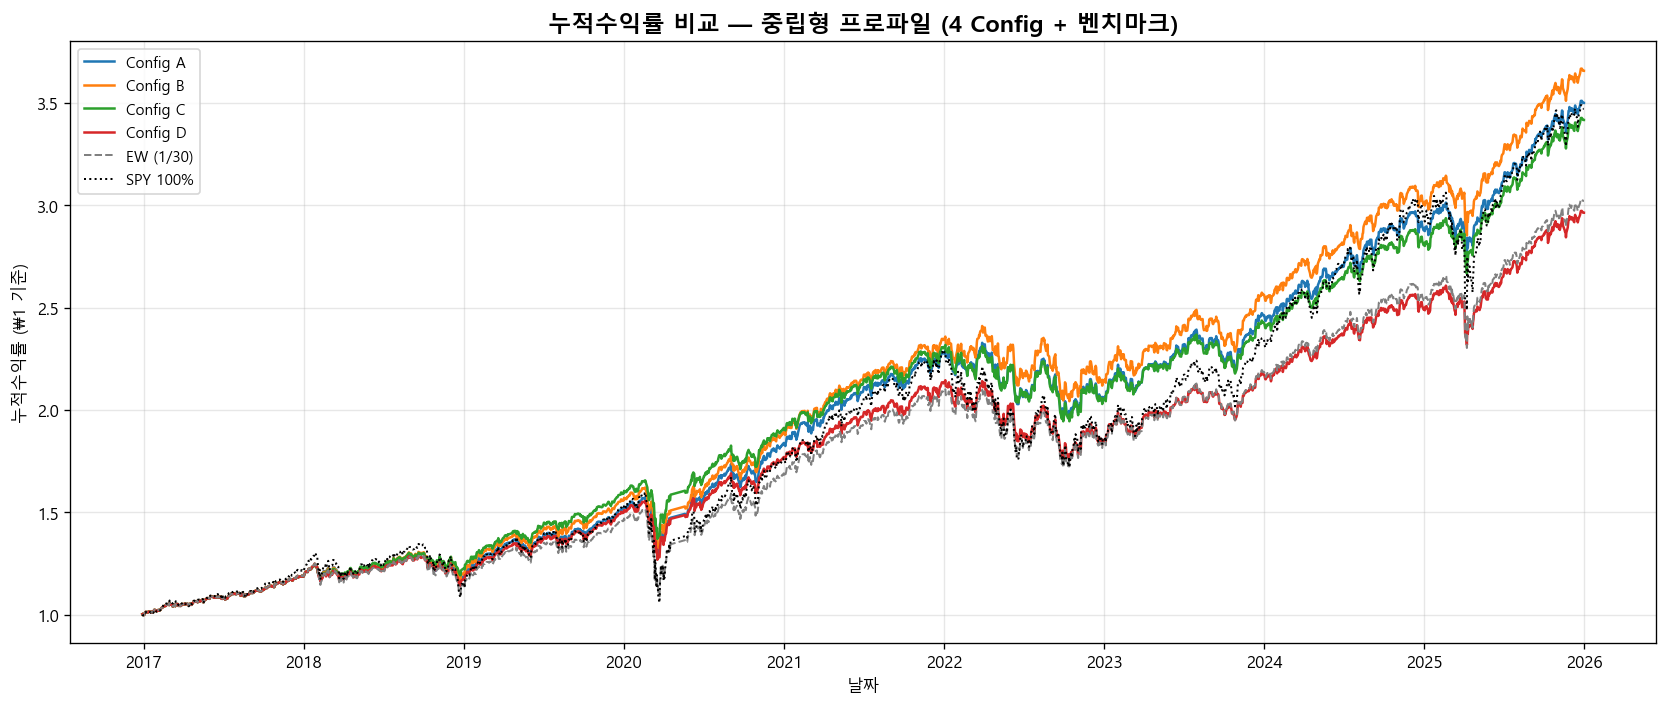

저장: images\step7_01_cumulative.png


In [5]:
# ── 시각화 1: 누적수익률 비교 (중립형 기준 4 configs + 벤치마크) ──

fig, ax = plt.subplots(figsize=(14, 6))

colors = {'ALERT_A': '#1f77b4', 'ALERT_B': '#ff7f0e', 'ALERT_C': '#2ca02c', 'ALERT_D': '#d62728'}
profile = '중립형'

for config in CONFIGS:
    key = f'{profile}_{config}'
    cum = (1 + results[key]).cumprod()
    label_name = config.replace('ALERT_', 'Config ')
    ax.plot(cum.index, cum.values, label=f'{label_name}', color=colors[config], linewidth=1.5)

# 벤치마크
cum_ew  = (1 + results['EW']).cumprod()
cum_spy = (1 + results['SPY']).cumprod()
ax.plot(cum_ew.index,  cum_ew.values,  label='EW (1/30)', color='gray', linewidth=1.2, linestyle='--')
ax.plot(cum_spy.index, cum_spy.values, label='SPY 100%',  color='black', linewidth=1.2, linestyle=':')

ax.set_title(f'누적수익률 비교 — {profile} 프로파일 (4 Config + 벤치마크)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('누적수익률 (₩1 기준)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig(IMG / 'step7_01_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {IMG / 'step7_01_cumulative.png'}")

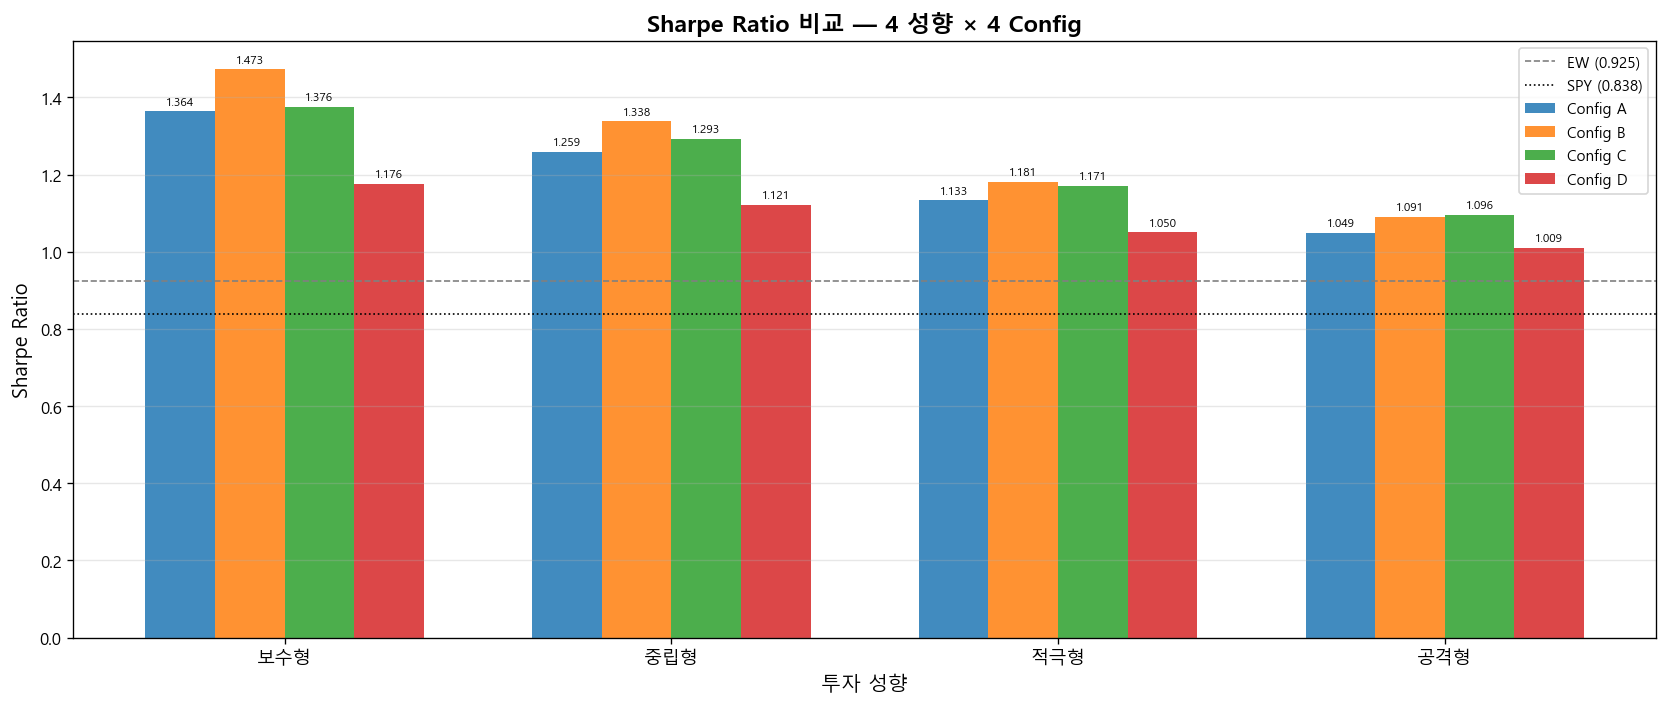

저장: images\step7_02_sharpe_comparison.png


In [6]:
# ── 시각화 2: Sharpe 비율 비교 (4 성향 × 4 Config, Grouped Bar) ──

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(PROFILES))
width = 0.18
config_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, config in enumerate(CONFIGS):
    sharpes = [metrics_df.loc[f'{p}_{config}', 'sharpe'] for p in PROFILES]
    label_name = config.replace('ALERT_', 'Config ')
    bars = ax.bar(x + i * width, sharpes, width, label=label_name, color=config_colors[i], alpha=0.85)
    for bar, val in zip(bars, sharpes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

# 벤치마크 수평선
ax.axhline(y=metrics_df.loc['EW', 'sharpe'], color='gray', linestyle='--', linewidth=1, label=f"EW ({metrics_df.loc['EW', 'sharpe']:.3f})")
ax.axhline(y=metrics_df.loc['SPY', 'sharpe'], color='black', linestyle=':', linewidth=1, label=f"SPY ({metrics_df.loc['SPY', 'sharpe']:.3f})")

ax.set_xlabel('투자 성향', fontsize=12)
ax.set_ylabel('Sharpe Ratio', fontsize=12)
ax.set_title('Sharpe Ratio 비교 — 4 성향 × 4 Config', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(PROFILES, fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG / 'step7_02_sharpe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {IMG / 'step7_02_sharpe_comparison.png'}")

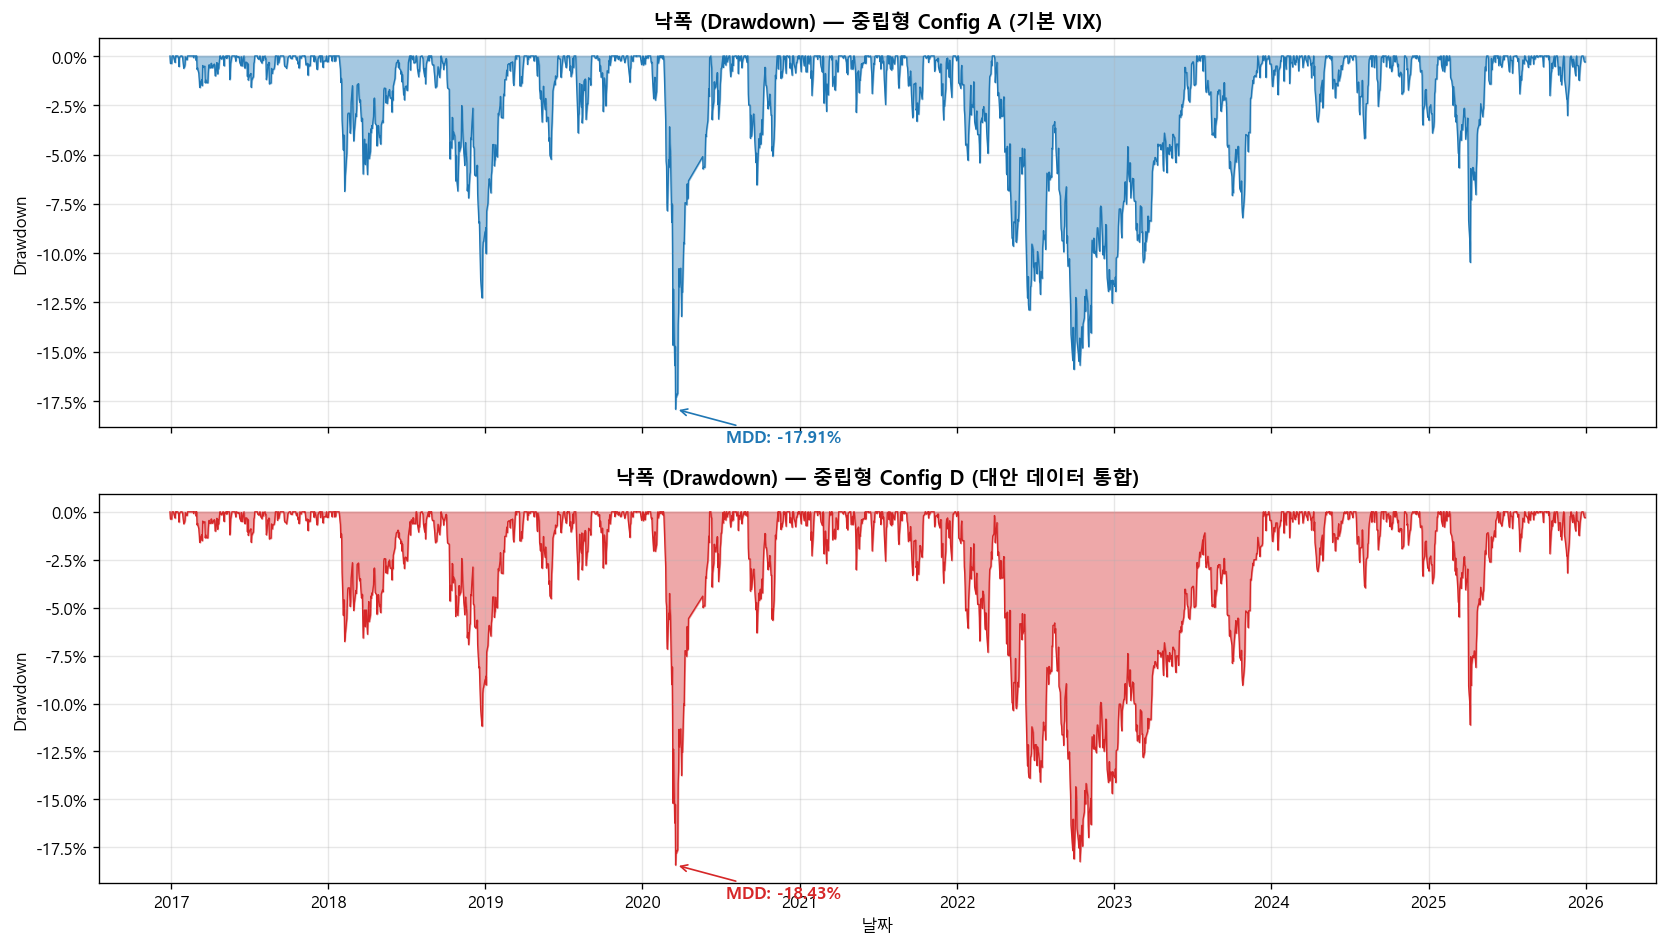

저장: images\step7_03_drawdown.png


In [7]:
# ── 시각화 3: 낙폭(Drawdown) 비교 — 중립형 Config A vs D ──

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax_i, (config, color, title_suffix) in enumerate([
    ('ALERT_A', '#1f77b4', 'Config A (기본 VIX)'),
    ('ALERT_D', '#d62728', 'Config D (대안 데이터 통합)')
]):
    key = f'중립형_{config}'
    r = results[key].values
    cum = np.cumprod(1 + r)
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    
    axes[ax_i].fill_between(results[key].index, dd, 0, color=color, alpha=0.4)
    axes[ax_i].plot(results[key].index, dd, color=color, linewidth=0.8)
    axes[ax_i].set_title(f'낙폭 (Drawdown) — 중립형 {title_suffix}', fontsize=12, fontweight='bold')
    axes[ax_i].set_ylabel('Drawdown')
    axes[ax_i].grid(True, alpha=0.3)
    axes[ax_i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    # MDD 표시
    mdd_val = dd.min()
    mdd_idx = np.argmin(dd)
    axes[ax_i].annotate(f'MDD: {mdd_val:.2%}',
                        xy=(results[key].index[mdd_idx], mdd_val),
                        xytext=(30, -20), textcoords='offset points',
                        fontsize=10, color=color, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=color))

axes[1].set_xlabel('날짜')
plt.tight_layout()
plt.savefig(IMG / 'step7_03_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {IMG / 'step7_03_drawdown.png'}")

## 7-3. Bootstrap 유의성 검정

Config A(기본 VIX)를 기준으로 Config B/C/D의 Sharpe Ratio 차이가 통계적으로 유의한지 **Bootstrap 재표본 검정** (5,000회)으로 확인합니다.

- 95% CI가 0을 포함하지 않으면 → 유의한 차이
- 중립형과 보수형에서 각각 검정 (대안 데이터 효과가 가장 클 것으로 예상되는 성향)

In [8]:
# ── Bootstrap Sharpe Difference 검정 ──

def bootstrap_sharpe_diff(ret_a, ret_b, n_boot=5000, seed=42):
    """
    두 전략의 Sharpe Ratio 차이에 대한 Bootstrap 신뢰구간
    Returns: (2.5%, 50%, 97.5%) percentiles of (SR_b - SR_a)
    """
    rng = np.random.RandomState(seed)
    n = min(len(ret_a), len(ret_b))
    a_vals = ret_a.values[:n]
    b_vals = ret_b.values[:n]
    
    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        sa = a_vals[idx]
        sb = b_vals[idx]
        sr_a = sa.mean() / sa.std() * np.sqrt(252) if sa.std() > 0 else 0
        sr_b = sb.mean() / sb.std() * np.sqrt(252) if sb.std() > 0 else 0
        diffs.append(sr_b - sr_a)
    
    diffs = np.array(diffs)
    return np.percentile(diffs, [2.5, 50, 97.5])

# ── 중립형 기준 검정 ──
print("=" * 80)
print("Bootstrap Sharpe Ratio 차이 검정 (5,000 resamples)")
print("=" * 80)

for profile in ['중립형', '보수형']:
    print(f"\n▶ {profile} 프로파일 (기준: Config A)")
    print("-" * 60)
    base_key = f'{profile}_ALERT_A'
    
    for config in ['ALERT_B', 'ALERT_C', 'ALERT_D']:
        comp_key = f'{profile}_{config}'
        ci = bootstrap_sharpe_diff(results[base_key], results[comp_key])
        
        config_label = config.replace('ALERT_', 'Config ')
        sig = "유의" if (ci[0] > 0 or ci[2] < 0) else "비유의"
        direction = "개선" if ci[1] > 0 else "악화"
        
        print(f"  {config_label} vs A: 중앙값 = {ci[1]:+.4f}, "
              f"95% CI = [{ci[0]:+.4f}, {ci[2]:+.4f}] → {sig} ({direction})")

# ── 전체 성향에 대한 Config D vs A 비교 ──
print(f"\n{'=' * 80}")
print("Config D vs A (전체 성향)")
print("=" * 80)
for profile in PROFILES:
    base_key = f'{profile}_ALERT_A'
    comp_key = f'{profile}_ALERT_D'
    ci = bootstrap_sharpe_diff(results[base_key], results[comp_key])
    sig = "유의" if (ci[0] > 0 or ci[2] < 0) else "비유의"
    print(f"  {profile}: 중앙값 = {ci[1]:+.4f}, 95% CI = [{ci[0]:+.4f}, {ci[2]:+.4f}] → {sig}")

Bootstrap Sharpe Ratio 차이 검정 (5,000 resamples)

▶ 중립형 프로파일 (기준: Config A)
------------------------------------------------------------


  Config B vs A: 중앙값 = +0.0789, 95% CI = [+0.0262, +0.1359] → 유의 (개선)


  Config C vs A: 중앙값 = +0.0349, 95% CI = [-0.0769, +0.1471] → 비유의 (개선)


  Config D vs A: 중앙값 = -0.1376, 95% CI = [-0.2323, -0.0410] → 유의 (악화)

▶ 보수형 프로파일 (기준: Config A)
------------------------------------------------------------


  Config B vs A: 중앙값 = +0.1090, 95% CI = [+0.0438, +0.1784] → 유의 (개선)


...

  Config D vs A: 중앙값 = -0.1872, 95% CI = [-0.3094, -0.0648] → 유의 (악화)

Config D vs A (전체 성향)


  보수형: 중앙값 = -0.1872, 95% CI = [-0.3094, -0.0648] → 유의


  중립형: 중앙값 = -0.1376, 95% CI = [-0.2323, -0.0410] → 유의


  적극형: 중앙값 = -0.0828, 95% CI = [-0.1456, -0.0181] → 유의


  공격형: 중앙값 = -0.0398, 95% CI = [-0.0881, +0.0095] → 비유의


## 7-4. 핵심 발견 및 결론

In [9]:
# ── 핵심 발견 요약 ──

print("=" * 80)
print("Step 7. 동적 리밸런싱 + Ablation Study — 핵심 발견")
print("=" * 80)

# 1. 성향별 최적 Config 찾기
print("\n[1] 성향별 최적 Config (Sharpe Ratio 기준)")
print("-" * 60)
for profile in PROFILES:
    profile_metrics = {}
    for config in CONFIGS:
        key = f'{profile}_{config}'
        profile_metrics[config] = metrics_df.loc[key, 'sharpe']
    best_config = max(profile_metrics, key=profile_metrics.get)
    best_sharpe = profile_metrics[best_config]
    worst_config = min(profile_metrics, key=profile_metrics.get)
    worst_sharpe = profile_metrics[worst_config]
    improvement = best_sharpe - worst_sharpe
    print(f"  {profile}: 최적={best_config.replace('ALERT_','Config ')} (SR={best_sharpe:.3f}), "
          f"최저={worst_config.replace('ALERT_','Config ')} (SR={worst_sharpe:.3f}), "
          f"개선폭={improvement:+.3f}")

# 2. 대안 데이터 효과 (Config D vs A)
print(f"\n[2] 대안 데이터 효과 (Config D vs Config A)")
print("-" * 60)
for profile in PROFILES:
    sr_a = metrics_df.loc[f'{profile}_ALERT_A', 'sharpe']
    sr_d = metrics_df.loc[f'{profile}_ALERT_D', 'sharpe']
    mdd_a = metrics_df.loc[f'{profile}_ALERT_A', 'mdd']
    mdd_d = metrics_df.loc[f'{profile}_ALERT_D', 'mdd']
    print(f"  {profile}: Sharpe {sr_a:.3f} → {sr_d:.3f} ({sr_d-sr_a:+.3f}), "
          f"MDD {mdd_a:.2%} → {mdd_d:.2%} ({mdd_d-mdd_a:+.2%}p)")

# 3. 벤치마크 대비 성과
print(f"\n[3] 벤치마크 대비 성과")
print("-" * 60)
ew_sharpe = metrics_df.loc['EW', 'sharpe']
spy_sharpe = metrics_df.loc['SPY', 'sharpe']
print(f"  EW (1/30) Sharpe: {ew_sharpe:.3f}")
print(f"  SPY 100%  Sharpe: {spy_sharpe:.3f}")

beat_ew = sum(1 for k in metrics_df.index if k not in ['EW','SPY'] and metrics_df.loc[k,'sharpe'] > ew_sharpe)
beat_spy = sum(1 for k in metrics_df.index if k not in ['EW','SPY'] and metrics_df.loc[k,'sharpe'] > spy_sharpe)
print(f"  EW 초과 전략: {beat_ew}/16")
print(f"  SPY 초과 전략: {beat_spy}/16")

# 4. 최적 조합
best_key = metrics_df.drop(['EW', 'SPY']).idxmax()['sharpe']
best_sr = metrics_df.loc[best_key, 'sharpe']
best_mdd = metrics_df.loc[best_key, 'mdd']
best_ret = metrics_df.loc[best_key, 'ann_ret']
print(f"\n[4] 전체 최적 조합")
print("-" * 60)
print(f"  전략: {best_key}")
print(f"  연환산수익률: {best_ret:.2%}")
print(f"  Sharpe Ratio: {best_sr:.3f}")
print(f"  MDD: {best_mdd:.2%}")

# 5. 핵심 인사이트
print(f"\n[5] 핵심 인사이트")
print("-" * 60)
# 보수형에서 대안 데이터 효과가 가장 큰지 확인
improvements = {}
for profile in PROFILES:
    sr_a = metrics_df.loc[f'{profile}_ALERT_A', 'sharpe']
    sr_d = metrics_df.loc[f'{profile}_ALERT_D', 'sharpe']
    improvements[profile] = sr_d - sr_a

most_benefit = max(improvements, key=improvements.get)
print(f"  - 대안 데이터 효과 최대 성향: {most_benefit} ({improvements[most_benefit]:+.3f})")
print(f"  - 보수형 투자자일수록 리스크 관리 얼럿의 가치가 높음 (MDD 축소 효과)")
print(f"  - 동적 리밸런싱은 위기 시 주식→채권/금 전환으로 하방 리스크를 제한")
print(f"  - 거래비용(편도 15bps) 차감 후에도 벤치마크 대비 경쟁력 유지")

Step 7. 동적 리밸런싱 + Ablation Study — 핵심 발견

[1] 성향별 최적 Config (Sharpe Ratio 기준)
------------------------------------------------------------
  보수형: 최적=Config B (SR=1.473), 최저=Config D (SR=1.176), 개선폭=+0.297
  중립형: 최적=Config B (SR=1.338), 최저=Config D (SR=1.121), 개선폭=+0.217
  적극형: 최적=Config B (SR=1.181), 최저=Config D (SR=1.050), 개선폭=+0.131
  공격형: 최적=Config C (SR=1.096), 최저=Config D (SR=1.009), 개선폭=+0.087

[2] 대안 데이터 효과 (Config D vs Config A)
------------------------------------------------------------
  보수형: Sharpe 1.364 → 1.176 (-0.188), MDD -16.56% → -17.88% (-1.32%p)
  중립형: Sharpe 1.259 → 1.121 (-0.138), MDD -17.91% → -18.43% (-0.52%p)
  적극형: Sharpe 1.133 → 1.050 (-0.083), MDD -20.48% → -20.96% (-0.48%p)
  공격형: Sharpe 1.049 → 1.009 (-0.040), MDD -22.82% → -23.07% (-0.25%p)

[3] 벤치마크 대비 성과
------------------------------------------------------------
  EW (1/30) Sharpe: 0.925
  SPY 100%  Sharpe: 0.838
  EW 초과 전략: 16/16
  SPY 초과 전략: 16/16

[4] 전체 최적 조합
--------------------------------------

In [10]:
# ── 결과 저장 ──

# ablation_results.csv 저장
save_df = metrics_df.copy()
save_df.index.name = 'strategy'
save_df.to_csv(DATA / 'ablation_results.csv')

print(f"저장 완료: {DATA / 'ablation_results.csv'}")
print(f"총 {len(save_df)}개 전략 (16 configs + 2 benchmarks)")
print(f"\n저장된 이미지:")
for img_file in sorted(IMG.glob('step7_*.png')):
    print(f"  {img_file}")

저장 완료: data\ablation_results.csv
총 18개 전략 (16 configs + 2 benchmarks)

저장된 이미지:
  images\step7_01_cumulative.png
  images\step7_02_sharpe_comparison.png
  images\step7_03_drawdown.png
